# 1. Dados essenciais

1.1 Dar mount no Drive e carregar o modelo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import tensorflow as tf
import numpy as np

# Caminho para o modelo
model_path = '/content/drive/My Drive/Projeto/modelos_salvos/TLSeg_128_9.keras'

try:
    # Carregar o modelo
    model = tf.keras.models.load_model(model_path)
    print("Modelo carregado com sucesso!")

    # Exibir o resumo da arquitetura
    model.summary()

except Exception as e:
    print(f"Erro ao carregar o modelo: {e}")

Mounted at /content/drive
Modelo carregado com sucesso!


Model: "EfficientNet_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,568,361 (47.94 MB)

 Trainable params: 4,174,592 (15.92 MB)

 Non-trainable params: 44,583 (174.16 KB)

 Optimizer params: 8,349,186 (31.85 MB)

1.2 Acessar o sub-modelo

In [ ]:
# O EfficientNetB0 está no índice 1, logo após o Input
# O nome 'efficientnetb0' veio do summary
inner_model = model.get_layer('efficientnetb0')

# 2. Definir o nome da camada alvo interna do EfficientNet
# 'top_activation' é o padrão do EfficientNet para a última camada de features antes do pooling
target_layer_name = 'top_activation'

try:
    # Tentar pegar a camada para ver se ela existe mesmo
    target_layer = inner_model.get_layer(target_layer_name)
    print(f"Sucesso - Camada '{target_layer_name}' encontrada dentro do EfficientNet.")
    print(f"Shape de saída da camada: {target_layer.output_shape}")

except ValueError:
    print(f"Erro: A camada '{target_layer_name}' não foi encontrada.")
    print("Listando as últimas 10 camadas do modelo interno para conferir:")
    for layer in inner_model.layers[-10:]:
        print(layer.name)

# É normal dar erro logo após de pegar a camada

Sucesso! Camada 'top_activation' encontrada dentro do EfficientNet.


AttributeError: 'Activation' object has no attribute 'output_shape'

1.3 Criar o Feature Extractor

In [ ]:
# O inner_model é 'efficientnetb0' do summary
last_conv_model = tf.keras.Model(inputs=inner_model.inputs, outputs=target_layer.output)

# 2. Criar o modelo classificador (O resto do modelo após o EfficientNet)
# Pega todas as camadas que vêm DEPOIS do efficientnetb0 no modelo original
classifier_input = tf.keras.Input(shape=target_layer.output.shape[1:])
x = classifier_input

# Encontrar onde o efficientnetb0 está na lista de camadas
eff_layer_index = model.layers.index(inner_model)

# Iterar sobre as camadas seguintes para recriar o cabeçalho de classificação
for layer in model.layers[eff_layer_index + 1:]:
    x = layer(x)

classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

print("--- Identificação concluída ---")
print(f"Extrator de Features: Entrada {last_conv_model.input_shape} -> Saída {last_conv_model.output_shape}")
print(f"Classificador: Entrada {classifier_model.input_shape} -> Saída {classifier_model.output_shape}")

--- Cirurgia concluída ---
Extrator de Features: Entrada (None, 128, 128, 3) -> Saída (None, 4, 4, 1280)
Classificador: Entrada (None, 4, 4, 1280) -> Saída (None, 4)


1.4 Verificar o tipo de pré-processamento

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# 1. Carrega a imagem original (pixels 0 a 255)
img_path = '/content/drive/My Drive/Projeto/testes/G_1.jpg' # <--- COLOCAR IMAGEM AQUI
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128, 128))
img_array = tf.keras.preprocessing.image.img_to_array(img) # Vira array numpy
img_batch = np.expand_dims(img_array, axis=0) # (1, 128, 128, 3)

print("--- Teste de Sanidade ---")
print("Classes identificadas: ['Normal', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']")

# CENÁRIO A: Passar 0 a 255 direto
# (Muitos EfficientNets salvos .keras já têm o rescale embutido)
pred_a = model.predict(img_batch, verbose=0)
score_a = np.max(pred_a)
print(f"A) Entrada 0-255: Confiança {score_a:.4f} -> Classe {np.argmax(pred_a)}")

# CENÁRIO B: Normalizar entre 0 e 1
pred_b = model.predict(img_batch / 255.0, verbose=0)
score_b = np.max(pred_b)
print(f"B) Entrada 0-1:   Confiança {score_b:.4f} -> Classe {np.argmax(pred_b)}")

# CENÁRIO C: Usar preprocess_input do Keras
img_preprocessed = preprocess_input(img_batch.copy())
pred_c = model.predict(img_preprocessed, verbose=0)
score_c = np.max(pred_c)
print(f"C) Preprocess Keras: Confiança {score_c:.4f} -> Classe {np.argmax(pred_c)}")

--- Teste de Sanidade ---
Classes identificadas: ['Normal', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
A) Entrada 0-255: Confiança 0.9993 -> Classe 1
B) Entrada 0-1:   Confiança 0.8289 -> Classe 0
C) Preprocess Keras: Confiança 0.9993 -> Classe 1


# 2. Implementação do Grad-CAM++


2.1 Ferramentas: Segmentação, Grad-CAM++ e lista de imagens


*   Somente rode uma vez antes do passo 2.2






In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os

# --- A. BANCO DE IMAGENS ---
banco_imagens = {
    "Normal": [
        '/content/drive/My Drive/Projeto/testes/N_100.jpg',
        '/content/drive/My Drive/Projeto/testes/N_102.jpg',
        '/content/drive/My Drive/Projeto/testes/N_106.jpg',
        '/content/drive/My Drive/Projeto/testes/N_109.jpg',
        '/content/drive/My Drive/Projeto/testes/N_123.jpg'
    ],
    "Glioma": [
        '/content/drive/My Drive/Projeto/testes/G_1.jpg',
        '/content/drive/My Drive/Projeto/testes/G_108.jpg',
        '/content/drive/My Drive/Projeto/testes/G_115.jpg',
        '/content/drive/My Drive/Projeto/testes/G_125.jpg',
        '/content/drive/My Drive/Projeto/testes/G_131.jpg'
    ],
    "Meningioma": [
        '/content/drive/My Drive/Projeto/testes/M_11.jpg',
        '/content/drive/My Drive/Projeto/testes/M_102.jpg',
        '/content/drive/My Drive/Projeto/testes/M_105.jpg',
        '/content/drive/My Drive/Projeto/testes/M_111.jpg',
        '/content/drive/My Drive/Projeto/testes/M_118.jpg'
    ],
    "Pituitary": [
        '/content/drive/My Drive/Projeto/testes/P_1.jpg',
        '/content/drive/My Drive/Projeto/testes/P_106.jpg',
        '/content/drive/My Drive/Projeto/testes/P_111.jpg',
        '/content/drive/My Drive/Projeto/testes/P_123.jpg',
        '/content/drive/My Drive/Projeto/testes/P_141.jpg'
    ]
}

# --- B. FUNÇÃO DE SEGMENTAÇÃO ---
def segment_image_cv(img_array_single):
    # Converte para uint8 para o OpenCV
    img = img_array_single.astype(np.uint8)

    # Pré-processamento
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0) # Blur levemente maior para reduzir ruído

    # Otsu simplificado (apenas THRESH_BINARY)
    # Fundo escuro -> 0 | Cérebro claro -> 255
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Aplica a máscara
    segmented = cv2.bitwise_and(img, img, mask=thresh)

    # Retorna float32 pronto para o modelo
    return segmented.astype(np.float32)

# --- C. FUNÇÃO GRAD-CAM++ (Com Segmentação + Normalização) ---
def gerar_gradcam_plus_plus(img_path, last_conv_model, classifier_model):
    # 1. Carregar
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128, 128))
    img_raw = tf.keras.preprocessing.image.img_to_array(img)

    # 2. Aplicar a segmentação
    img_segmented = segment_image_cv(img_raw)

    # 3. Preparar para o modelo
    # IMPORTANTE: Se o modelo espera 0-255, então NÃO divide por 255
    img_batch = np.expand_dims(img_segmented, axis=0)

    # 4. Calcular gradientes
    with tf.GradientTape() as tape_1:
        with tf.GradientTape() as tape_2:
            with tf.GradientTape() as tape_3:
                conv_outputs = last_conv_model(img_batch)
                predictions = classifier_model(conv_outputs)
                best_class_index = tf.argmax(predictions[0])
                loss = predictions[:, best_class_index]

            first_grads = tape_3.gradient(loss, conv_outputs)
        second_grads = tape_2.gradient(first_grads, conv_outputs)
    third_grads = tape_1.gradient(second_grads, conv_outputs)

    # 5. Matemática do Grad-CAM++
    global_sum = np.sum(conv_outputs, axis=(0, 1, 2))
    alpha_num = second_grads[0]
    alpha_denom = 2.0 * second_grads[0] + global_sum * third_grads[0]
    alpha_denom = np.where(alpha_denom != 0.0, alpha_denom, 1e-10)

    alphas = alpha_num / alpha_denom
    alphas_norm = np.sum(alphas, axis=(0,1))
    alphas_norm = np.where(alphas_norm != 0.0, alphas_norm, 1e-10)
    alphas /= alphas_norm

    weights = np.maximum(first_grads[0], 0.0)
    deep_linearization_weights = np.sum(weights * alphas, axis=(0,1))

    heatmap = np.sum(conv_outputs[0] * deep_linearization_weights, axis=-1)
    heatmap = np.maximum(heatmap, 0) # ReLU

    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap) # Normalização do heatmap para 0-1

    return heatmap, img_segmented, best_class_index

print("Ferramentas carregadas - Pode ir para a execução do Grad-CAM++.")

✅ Ferramentas carregadas! Pode ir para o próximo bloco.


2.2 Execução do Grad-CAM++
*  Execute uma vez por classe. Mude ``` CLASSE_ALVO ``` para o nome da classe que quer aplicar o Grad-CAM++


In [ ]:
# ==========================================
# ESCOLHA A CLASSE AQUI
# #Normal #Glioma #Meningioma #Pituitary
# ==========================================
CLASSE_ALVO = "Meningioma"
# ==========================================

# Cria pasta para salvar
output_folder = f'/content/drive/My Drive/Projeto/GradCAM_Resultados/{CLASSE_ALVO}/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print(f"--- Processando Grad-CAM++ para: {CLASSE_ALVO} ---")

lista_imgs = banco_imagens[CLASSE_ALVO]

for i, img_path in enumerate(lista_imgs):
    filename = os.path.basename(img_path)
    print(f"[{i+1}/5] Gerando para: {filename}...")

    try:
        # Chama a função mestre
        heatmap, img_seg, pred_idx = gerar_gradcam_plus_plus(img_path, last_conv_model, classifier_model)

        # --- VISUALIZAÇÃO ---
        # 1. Heatmap colorido
        heatmap_resized = cv2.resize(heatmap, (128, 128))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        # 2. Superposição (Usando a imagem segmentada como base)
        img_seg_uint8 = img_seg.astype(np.uint8)
        superimposed = (img_seg_uint8 * 0.6 + heatmap_colored * 0.4).astype(np.uint8)

        # 3. Plotar (3 colunas: Segmentada | Heatmap puro | Resultado)
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.title(f"Segmentada (Entrada)")
        plt.imshow(img_seg_uint8)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Heatmap Grad-CAM++")
        plt.imshow(heatmap_resized, cmap='jet')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title(f"Predição: Classe {pred_idx}")
        plt.imshow(superimposed)
        plt.axis('off')

        # Salvar
        save_path = os.path.join(output_folder, f"GradCAM_{filename}")
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.close()

        print(f"    -> Salvo em: {save_path}")

    except Exception as e:
        print(f"    -> ERRO em {filename}: {e}")

print(f"\n {CLASSE_ALVO} concluído.")

--- Processando Grad-CAM++ para: Meningioma ---
[1/5] Gerando para: M_11.jpg...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


    -> Salvo em: /content/drive/My Drive/Projeto/GradCAM_Resultados/Meningioma/GradCAM_M_11.jpg
[2/5] Gerando para: M_102.jpg...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


    -> Salvo em: /content/drive/My Drive/Projeto/GradCAM_Resultados/Meningioma/GradCAM_M_102.jpg
[3/5] Gerando para: M_105.jpg...


...

    -> Salvo em: /content/drive/My Drive/Projeto/GradCAM_Resultados/Meningioma/GradCAM_M_105.jpg
[4/5] Gerando para: M_111.jpg...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


    -> Salvo em: /content/drive/My Drive/Projeto/GradCAM_Resultados/Meningioma/GradCAM_M_111.jpg
[5/5] Gerando para: M_118.jpg...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


    -> Salvo em: /content/drive/My Drive/Projeto/GradCAM_Resultados/Meningioma/GradCAM_M_118.jpg

✅ Meningioma concluído!


# 3. Implementação do LIME


3.1 Configurações iniciais (Sempre rodar assim que abrir o Colab)

In [ ]:
# --- CÉLULA DE INICIALIZAÇÃO ---

# 1. Instalar bibliotecas externas
!pip install lime

# 2. Conectar ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Importar tudo o que precisa
import tensorflow as tf
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# 4. Carregar seu modelo
caminho_modelo = '/content/drive/My Drive/Projeto/modelos_salvos/TLSeg_128_6.keras'
try:
    model = tf.keras.models.load_model(caminho_modelo)
    print("Modelo carregado com sucesso.")
except:
    print("ERRO: Não esqueça de ajustar o caminho do modelo acima.")

# 5. Banco de imagens
banco_imagens = {
    "Normal": [
        '/content/drive/My Drive/Projeto/testes/N_100.jpg',
        '/content/drive/My Drive/Projeto/testes/N_102.jpg',
        '/content/drive/My Drive/Projeto/testes/N_106.jpg',
        '/content/drive/My Drive/Projeto/testes/N_109.jpg',
        '/content/drive/My Drive/Projeto/testes/N_123.jpg'
    ],
    "Glioma": [
        '/content/drive/My Drive/Projeto/testes/G_1.jpg',
        '/content/drive/My Drive/Projeto/testes/G_108.jpg',
        '/content/drive/My Drive/Projeto/testes/G_115.jpg',
        '/content/drive/My Drive/Projeto/testes/G_125.jpg',
        '/content/drive/My Drive/Projeto/testes/G_131.jpg'
    ],
    "Meningioma": [
        '/content/drive/My Drive/Projeto/testes/M_11.jpg',
        '/content/drive/My Drive/Projeto/testes/M_102.jpg',
        '/content/drive/My Drive/Projeto/testes/M_105.jpg',
        '/content/drive/My Drive/Projeto/testes/M_111.jpg',
        '/content/drive/My Drive/Projeto/testes/M_118.jpg'
    ],
    "Pituitary": [
        '/content/drive/My Drive/Projeto/testes/P_1.jpg',
        '/content/drive/My Drive/Projeto/testes/P_106.jpg',
        '/content/drive/My Drive/Projeto/testes/P_111.jpg',
        '/content/drive/My Drive/Projeto/testes/P_123.jpg',
        '/content/drive/My Drive/Projeto/testes/P_141.jpg'
    ]
}

# 6. Função de segmentação
def segment_image_cv(img_array_single):
    # Converte para uint8
    img = img_array_single.astype(np.uint8)

    # Pré-processamento
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Otsu simplificado (Fundo=0, Cérebro=255)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Aplica máscara
    segmented = cv2.bitwise_and(img, img, mask=thresh)

    # Retorna float32 (mas valores entre 0-255)
    return segmented.astype(np.float32)

# 7. Preparar o LIME
explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    # O LIME manda um batch de imagens
    # O modelo já espera imagens 0-255 segmentadas
    return model.predict(images, verbose=0)

print("Sucesso - Segmentação carregada e LIME configurado.")

# para Normal: N_100; N_102; N_106; N_109; N_123 -> Classe 0
# para Glioma: G_1; G_108; G_115; G_125; G_131 -> Classe 1
# para Meningioma: M_11; M_102; M_105; M_111; M_118 -> Classe 2
# para Pituitary: P_1; P_106; P_111; P_123; P_141 -> Classe 3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=741acd3968ff49bbdbfe1dffbf44122f921525c4285f8a59a27ed4b3a696b73f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modelo carregado com sucesso!
🚀 Tudo pronto! Segmentação carregada e LIME configurado.


3.2 Execução do LIME por classe

*   Para mudar a classe, somente edite ``` CLASSE_ALVO ```




In [ ]:
# ==========================================
# ESCOLHA A CLASSE AQUI
# #Normal #Glioma #Meningioma #Pituitary
# ==========================================
CLASSE_ALVO = "Pituitary"
# ==========================================

# Cria pasta para salvar
output_folder = f'/content/drive/My Drive/Projeto/LIME_Resultados/{CLASSE_ALVO}/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print(f"--- Processando LIME para: {CLASSE_ALVO} ---")
print("Aviso: O LIME é lento. Espere cerca de 40-60s por imagem.")

lista_imgs = banco_imagens[CLASSE_ALVO]

for i, img_path in enumerate(lista_imgs):
    filename = os.path.basename(img_path)
    print(f"\n[{i+1}/5] Gerando para: {filename}...")

    try:
        # A. Carregar
        img_orig = tf.keras.preprocessing.image.load_img(img_path, target_size=(128, 128))
        img_raw = tf.keras.preprocessing.image.img_to_array(img_orig)

        # B. Segmentar
        img_segmented = segment_image_cv(img_raw)

        # Converter para double (requisito do LIME)
        img_lime = img_segmented.astype('double')

        # C. Executar LIME
        # num_samples=1000 é o ideal. Se tiver pressa, abaixar para 800
        explanation = explainer.explain_instance(
            img_lime,
            predict_fn,
            top_labels=1,
            hide_color=0,
            num_samples=1000
        )

        # D. Visualização lado a lado (comparativo)
        top_class = explanation.top_labels[0]

        # Pega imagem e máscara (apenas 5 superpixels mais importantes)
        temp, mask = explanation.get_image_and_mask(
            top_class,
            positive_only=True,
            num_features=5,
            hide_rest=False
        )

        # Plotagem
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        # Esquerda: segmentada original
        ax1.imshow(img_segmented.astype('uint8'))
        ax1.set_title("Entrada (Segmentada)")
        ax1.axis('off')

        # Direita: explicação LIME
        ax2.imshow(mark_boundaries(temp / 255.0, mask))
        ax2.set_title(f"LIME - Foco Classe {top_class}")
        ax2.axis('off')

        # Salvar
        save_path = os.path.join(output_folder, f"LIME_{filename}")
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.close() # Libera memória

        print(f"    -> Salvo em: {save_path}")

    except Exception as e:
        print(f"    -> ERRO em {filename}: {e}")

print(f"\n {CLASSE_ALVO} concluído.")

--- Processando LIME para: Pituitary ---
⚠️ Aviso: O LIME é lento. Espere cerca de 40-60s por imagem.

[1/5] Gerando para: P_1.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_1.jpg

[2/5] Gerando para: P_106.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_106.jpg

[3/5] Gerando para: P_111.jpg...


...

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_111.jpg

[4/5] Gerando para: P_123.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_123.jpg

[5/5] Gerando para: P_141.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_141.jpg

✅ Pituitary concluído!


3.3 Rodar o LIME (Processamento)

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
import tensorflow as tf

# 1. Função automática com Segmentação
def processar_classe_lime(nome_classe):
    # Verifica se a classe existe
    if nome_classe not in banco_imagens:
        print(f"Erro: Classe '{nome_classe}' não encontrada no banco.")
        return

    lista_atual = banco_imagens[nome_classe]
    output_folder = f'/content/drive/My Drive/Projeto/LIME_Resultados/{nome_classe}/'

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    print(f"--- Iniciando LIME para {nome_classe} ---")

    for i, img_path in enumerate(lista_atual):
        filename = os.path.basename(img_path)
        print(f"[{i+1}/5] Processando: {filename}...")

        try:
            # A. Carregar imagem bruta
            img_orig = tf.keras.preprocessing.image.load_img(img_path, target_size=(128, 128))
            img_raw = tf.keras.preprocessing.image.img_to_array(img_orig)

            # B. Aplicar segmentação
            # Remove o fundo antes do LIME ver a imagem
            img_segmented = segment_image_cv(img_raw)

            # C. Preparar para LIME
            img_lime = img_segmented.astype('double')

            # D. Rodar LIME
            explanation = explainer.explain_instance(
                img_lime,
                predict_fn,
                top_labels=1,
                hide_color=0,
                num_samples=1000
            )

            # E. Visualização lado a lado
            top_class = explanation.top_labels[0]
            temp, mask = explanation.get_image_and_mask(
                top_class, positive_only=True, num_features=5, hide_rest=False
            )

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

            # Esquerda: Imagem limpa (segmentada)
            ax1.imshow(img_segmented.astype('uint8'))
            ax1.set_title("Entrada (Segmentada)")
            ax1.axis('off')

            # Direita: Explicação
            ax2.imshow(mark_boundaries(temp / 255.0, mask))
            ax2.set_title(f"LIME - Classe {top_class}")
            ax2.axis('off')

            # Salvar
            save_path = os.path.join(output_folder, f"LIME_{filename}")
            plt.savefig(save_path, bbox_inches='tight', dpi=150)
            plt.close() # Limpa memória

            print(f"    -> Salvo em: {save_path}.")

        except Exception as e:
            print(f"    -> Erro em {filename}: {e}")

    print(f" {nome_classe} Finalizado.\n")

In [ ]:
processar_classe_lime("Normal")
processar_classe_lime("Glioma")
processar_classe_lime("Meningioma")
processar_classe_lime("Pituitary")

--- Iniciando LIME para Normal ---
[1/5] Processando: N_100.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Normal/LIME_N_100.jpg.
[2/5] Processando: N_102.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Normal/LIME_N_102.jpg.
[3/5] Processando: N_106.jpg...


...

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_111.jpg.
[4/5] Processando: P_123.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_123.jpg.
[5/5] Processando: P_141.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo em: /content/drive/My Drive/Projeto/LIME_Resultados/Pituitary/LIME_P_141.jpg.
✅ Pituitary Finalizado!



3.4 Visualizar o resultado

*   Opção 1: O "Comparativo" (Ideal para Slides)

**O que ela te dá:** Duas imagens coladas. A original e a explicada.

**Por que usar:** É a melhor para slides. Ela evita que você tenha que ficar alternando imagens. Você mostra o tumor original e, ao lado, prova que o LIME "circulou" exatamente aquela massa.


---
*   Opção 2: O "Prós e Contras" (Diagnóstico Profundo)

**O que ela te dá:** Uma imagem com bordas de duas cores (geralmente verde para o que confirma a classe e vermelho para o que confunde o modelo).

**Por que usar:** É excelente para análise técnica. Se o modelo errou uma predição, essa opção revela o porquê. Às vezes, o modelo vê o tumor (verde), mas vê uma sombra no osso que o faz duvidar (vermelho).


---
*   Opção 3: O "Foco Total" (Isolamento)

**O que ela te dá:** Tudo o que não é importante desaparece (fica preto). Sobram apenas os "pedaços" que o modelo considerou cruciais.

**Por que usar:** É a mais impactante visualmente. Se o modelo estiver viciado (olhando para o fundo da imagem em vez do cérebro), essa opção vai mostrar apenas um fundo preto vazio ou áreas aleatórias, "denunciando" o erro do modelo.


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ==============================================================================
# CONFIGURAÇÃO DA RODADA
# ==============================================================================
CLASSE_ALVO = "Pituitary"   # Opções: "Normal", "Glioma", "Meningioma", "Pituitary"
OPCAO_VISUAL = 3         # 1 = Comparativo | 2 = Prós/Contras | 3 = Isolamento (Fundo Preto)
# ==============================================================================

def rodar_lime_em_lote(nome_classe, opcao):

    # Validação básica
    if nome_classe not in banco_imagens:
        print(f"❌ Erro: Classe '{nome_classe}' não existe no banco_imagens.")
        return

    # Define pasta de saída baseada na opção escolhida
    nome_opcao = f"Opcao_{opcao}"
    output_folder = f'/content/drive/My Drive/Projeto/LIME_Resultados/{nome_classe}/{nome_opcao}/'

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    lista_imgs = banco_imagens[nome_classe]
    print(f"--- Iniciando LIME (Estilo {opcao}) para {nome_classe} ---")

    for i, img_path in enumerate(lista_imgs):
        filename = os.path.basename(img_path)
        print(f"[{i+1}/5] Processando: {filename}...")

        try:
            # 1. CARREGAR E SEGMENTAR (Sempre igual)
            img_orig = tf.keras.preprocessing.image.load_img(img_path, target_size=(128, 128))
            img_raw = tf.keras.preprocessing.image.img_to_array(img_orig)
            img_segmented = segment_image_cv(img_raw) # Usa sua função de Otsu
            img_lime = img_segmented.astype('double')

            # 2. RODAR O LIME
            explanation = explainer.explain_instance(
                img_lime, predict_fn, top_labels=1, hide_color=0, num_samples=1000
            )
            top_class = explanation.top_labels[0]

            # 3. CONFIGURAR A VISUALIZAÇÃO
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

            # Título comum para a esquerda
            ax1.imshow(img_segmented.astype('uint8'))
            ax1.set_title("Entrada (Segmentada)")
            ax1.axis('off')

            # LÓGICA DAS OPÇÕES
            if opcao == 1: # LADO A LADO (Padrão)
                temp, mask = explanation.get_image_and_mask(
                    top_class, positive_only=True, num_features=5, hide_rest=False
                )
                ax2.imshow(mark_boundaries(temp / 255.0, mask))
                ax2.set_title(f"LIME: Foco Principal (Classe {top_class})")

            elif opcao == 2: # PRÓS E CONTRAS (Verde/Vermelho)
                temp, mask = explanation.get_image_and_mask(
                    top_class, positive_only=False, num_features=8, hide_rest=False
                )
                ax2.imshow(mark_boundaries(temp / 255.0, mask))
                ax2.set_title(f"Verde: Confirma | Vermelho: Contradiz")

            elif opcao == 3: # ISOLAMENTO (Fundo preto)
                temp, mask = explanation.get_image_and_mask(
                    top_class, positive_only=True, num_features=5, hide_rest=True
                )
                ax2.imshow(mark_boundaries(temp / 255.0, mask))
                ax2.set_title(f"Apenas Áreas Vitais (Isoladas)")

            ax2.axis('off')

            # 4. SALVAR
            # O nome do arquivo inclui a opção para não misturar
            nome_arquivo = f"LIME_Op{opcao}_{filename}"
            save_path = os.path.join(output_folder, nome_arquivo)

            plt.tight_layout()
            plt.savefig(save_path, bbox_inches='tight', dpi=150)
            plt.close() # Fecha para não travar a memória RAM

            print(f"    -> Salvo: {nome_arquivo}")

        except Exception as e:
            print(f"    -> Erro em {filename}: {e}")

    print(f"\n✅ {nome_classe} (Opção {opcao}) Finalizado! Verifique a pasta no Drive.")

# --- EXECUTAR ---
rodar_lime_em_lote(CLASSE_ALVO, OPCAO_VISUAL)

--- Iniciando LIME (Estilo 3) para Pituitary ---
[1/5] Processando: P_1.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo: LIME_Op3_P_1.jpg
[2/5] Processando: P_106.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo: LIME_Op3_P_106.jpg
[3/5] Processando: P_111.jpg...


...

    -> Salvo: LIME_Op3_P_111.jpg
[4/5] Processando: P_123.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo: LIME_Op3_P_123.jpg
[5/5] Processando: P_141.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Salvo: LIME_Op3_P_141.jpg

✅ Pituitary (Opção 3) Finalizado! Verifique a pasta no Drive.


# 4. Implementação do SHAP


In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import shap

# --- 1. BANCO DE IMAGENS ---
banco_imagens = {
    "Normal": [
        '/content/drive/My Drive/Projeto/testes/N_100.jpg',
        '/content/drive/My Drive/Projeto/testes/N_102.jpg',
        '/content/drive/My Drive/Projeto/testes/N_106.jpg',
        '/content/drive/My Drive/Projeto/testes/N_109.jpg',
        '/content/drive/My Drive/Projeto/testes/N_123.jpg'
    ],
    "Glioma": [
        '/content/drive/My Drive/Projeto/testes/G_1.jpg',
        '/content/drive/My Drive/Projeto/testes/G_108.jpg',
        '/content/drive/My Drive/Projeto/testes/G_115.jpg',
        '/content/drive/My Drive/Projeto/testes/G_125.jpg',
        '/content/drive/My Drive/Projeto/testes/G_131.jpg'
    ],
    "Meningioma": [
        '/content/drive/My Drive/Projeto/testes/M_11.jpg',
        '/content/drive/My Drive/Projeto/testes/M_102.jpg',
        '/content/drive/My Drive/Projeto/testes/M_105.jpg',
        '/content/drive/My Drive/Projeto/testes/M_111.jpg',
        '/content/drive/My Drive/Projeto/testes/M_118.jpg'
    ],
    "Pituitary": [
        '/content/drive/My Drive/Projeto/testes/P_1.jpg',
        '/content/drive/My Drive/Projeto/testes/P_106.jpg',
        '/content/drive/My Drive/Projeto/testes/P_111.jpg',
        '/content/drive/My Drive/Projeto/testes/P_123.jpg',
        '/content/drive/My Drive/Projeto/testes/P_141.jpg'
    ]
}

# --- 2. FUNÇÃO DE SEGMENTAÇÃO ---
def segment_image_cv(img_array_single):
    img = img_array_single.astype(np.uint8)
    # Garante a escala de cinza para o Otsu
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Pré-processamento: Median Blur é ideal para ruídos tipo sal-e-pimenta
    blurred = cv2.medianBlur(gray, 5)

    # 1. Gera máscara inicial com Otsu (ela virá com buracos internos)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # --- NOVA ETAPA: DETECÇÃO DO MAIOR CONTORNO ---

    # 2. Encontra todos os contornos na máscara
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Cria uma máscara preta do tamanho da imagem
    final_mask = np.zeros_like(gray)

    if contours:
        # 3. Encontra o maior contorno baseado na área
        largest_contour = max(contours, key=cv2.contourArea)

        # 4. Desenha apenas o maior contorno e preenche por dentro (-1)
        # Gera uma máscara sólida da cabeça, sem buracos internos
        cv2.drawContours(final_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

        # 5. Erosão forte para remover o osso (só afetará a borda externa)
        kernel = np.ones((5, 5), np.uint8)
        # iterations=2 (deve remover bem o crânio)
        final_mask = cv2.erode(final_mask, kernel, iterations=2)

    # 6. Aplica a máscara final e limpa na imagem original
    segmented = cv2.bitwise_and(img, img, mask=final_mask)

    return segmented.astype(np.float32)


# --- 3. PREPARAR O BACKGROUND DATA ---
background_images = []

for classe, caminhos in banco_imagens.items():
    # Pega apenas as 3 primeiras imagens de cada classe
    for caminho in caminhos[:3]:
        img = tf.keras.preprocessing.image.load_img(caminho, target_size=(128, 128))
        img_raw = tf.keras.preprocessing.image.img_to_array(img)

        img_segmented = segment_image_cv(img_raw)
        background_images.append(img_segmented)

# Converte a lista para um array NumPy (mantendo os valores de 0 a 255)
background_data = np.array(background_images)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:32, 32.41s/it]               


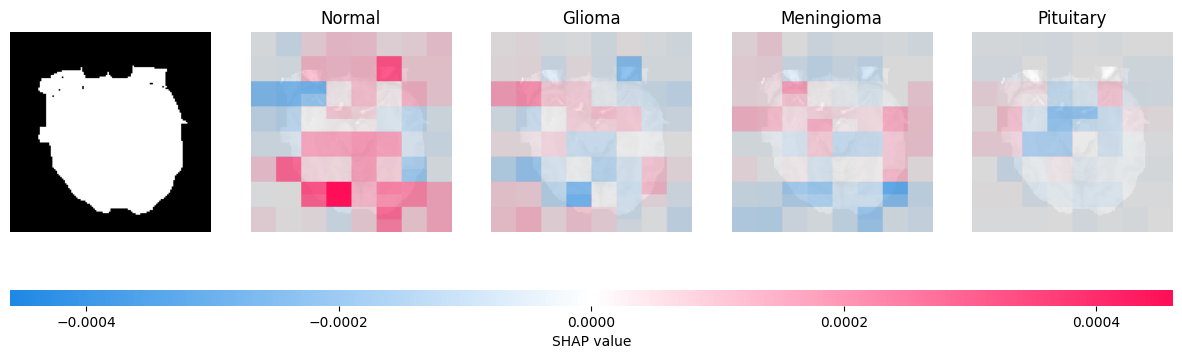

In [ ]:
# --- 4. CARREGAR O MODELO E CRIAR FUNÇÃO DE PREDIÇÃO ---
model_path = '/content/drive/My Drive/Projeto/modelos_salvos/TLSeg_128_9.keras'
model = tf.keras.models.load_model(model_path)

# O SHAP de "caixa preta" precisa apenas de uma função que receba imagens e devolva as predições
def predict_fn(imagens):
    return model.predict(imagens, verbose=0)

# --- 5. PREPARAR A IMAGEM DE TESTE ---
caminho_teste = banco_imagens["Normal"][0]
img_teste = tf.keras.preprocessing.image.load_img(caminho_teste, target_size=(128, 128))
img_raw_teste = tf.keras.preprocessing.image.img_to_array(img_teste)
img_seg_teste = segment_image_cv(img_raw_teste)

# Batch de teste: (1, 128, 128, 3)
img_teste_batch = np.expand_dims(img_seg_teste, axis=0)

# --- 6. CONFIGURAR O EXPLICADOR (Black-Box) ---
# O 'masker' ensina o SHAP como "esconder" partes da imagem
# Nesse caso tá usando o desfoque (blur)
masker = shap.maskers.Image("blur(128,128)", img_teste_batch[0].shape)

# Criar o Explainer passando as classes para o gráfico ficar top
classes = ["Normal", "Glioma", "Meningioma", "Pituitary"]
explainer = shap.Explainer(predict_fn, masker, output_names=classes)

# --- 7. CALCULAR OS VALORES SHAP ---
# max_evals limita quantas vezes ele roda o predict
# 500 é um bom limite para testes na CPU
shap_values = explainer(img_teste_batch, max_evals=500, batch_size=50)

# --- 8. VISUALIZAR ---
shap.image_plot(shap_values)

Caso seja necessário verificar somente a segmentação, rodar:

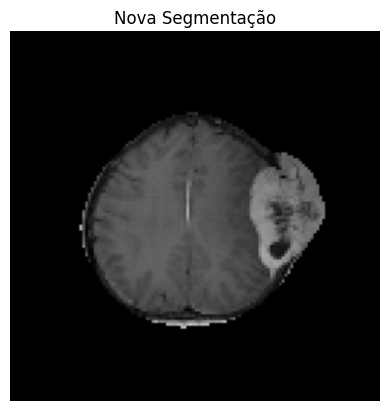

In [ ]:
import matplotlib.pyplot as plt

# 1. Carrega a imagem
caminho_teste = banco_imagens["Meningioma"][4]
img_teste = tf.keras.preprocessing.image.load_img(caminho_teste, target_size=(128, 128))
img_raw_teste = tf.keras.preprocessing.image.img_to_array(img_teste)

# 2. Aplica a NOVA segmentação (certifique-se de ter rodado a célula com a função atualizada antes)
img_seg_teste = segment_image_cv(img_raw_teste)

# 3. Plota o resultado (convertendo para uint8 apenas para o matplotlib exibir as cores corretamente)
plt.imshow(img_seg_teste.astype(np.uint8))
plt.title("Nova Segmentação")
plt.axis('off')
plt.show()